## Step 1: Install Required Packages

In [1]:
!pip install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 91.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


## Step 2: Download Dataset from Roboflow

In [2]:
from roboflow import Roboflow

# Initialize Roboflow with your API key
rf = Roboflow(api_key="xwbQNSeTGsWM0tWBRIjv")

# Download the dataset
project = rf.workspace("ashwath-oh952").project("indian-sign-language-detection-dxgag")
version = project.version(1)
dataset = version.download("yolov8")

print("\nDataset downloaded successfully!")
print(f"Dataset location: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Indian-Sign-Language-Detection-1 in yolov8:: 100%|██████████| 8354/8354 [00:00<00:00, 9800.57it/s] 


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Dataset downloaded successfully!
Dataset location: /content/Indian-Sign-Language-Detection-1


## Step 3: Train YOLOv8 Model

In [3]:

from ultralytics import YOLO
from pathlib import Path

# Path to dataset YAML file
DATASET_DIR = Path("Indian-Sign-Language-Detection-1")  # Update if different
data_yaml = DATASET_DIR / "data.yaml"

print(f"Training with data from: {data_yaml}")

# Load pre-trained YOLOv8 model
model = YOLO("yolov8s.pt")  # yolov8s = small model

# Train the model
results = model.train(
    data=str(data_yaml),
    epochs=80,           # Increase to 100+ for better accuracy
    imgsz=640,           # Image size
    batch=16,            # Batch size (adjust based on GPU memory)
    workers=2,           # Number of workers
    project="runs",      # Project directory
    name="isl_public_yolov8",  # Experiment name
    verbose=True,
    device=0             # Use GPU (0 for first GPU)
)

print("\n" + "="*50)
print("Training completed!")
print("Best weights saved at: runs/detect/isl_public_yolov8/weights/best.pt")
print("="*50)

Training with data from: Indian-Sign-Language-Detection-1/data.yaml
Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Indian-Sign-Language-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=isl_public_yolov8, nbs=64, nms=False, opset=None, optimize=

## Step 4: Evaluate Model Performance

In [4]:
# Validate the trained model
metrics = model.val()

print(f"\nValidation Results:")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,139,129 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 797.8±116.7 MB/s, size: 19.7 KB)
val: Scanning /content/Indian-Sign-Language-Detection-1/valid/labels.cache... 341 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 341/341 611.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 3.6it/s 6.1s
                   all        341        344      0.969      0.968      0.983      0.866
                     1          9          9      0.979          1      0.995      0.747
                     2         12         12      0.995          1      0.995      0.858
                     3         11         11      0.936          1      0.995      0.889
                     4         10         10      0.897          1      0.995      0.861
                     5

## Step 5: Test on Sample Images

Using model from training step (Step 3)

image 1/1 /content/Indian-Sign-Language-Detection-1/valid/images/828_jpg.rf.3c71cb2d5048abd64b03c11aa4d9499c.jpg: 640x640 1 3, 16.3ms
Speed: 2.9ms preprocess, 16.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


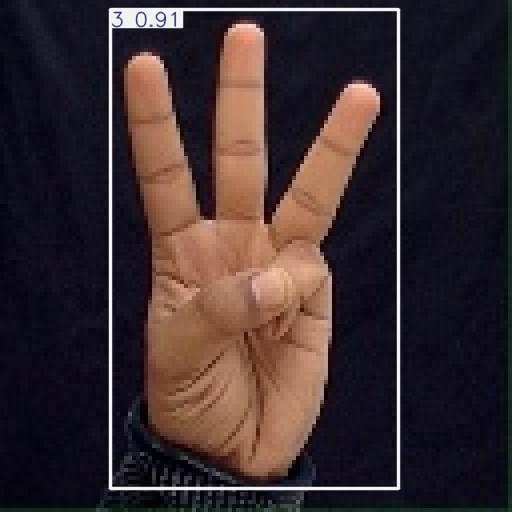


Detections for 828_jpg.rf.3c71cb2d5048abd64b03c11aa4d9499c.jpg:
  - 3: 0.91

image 1/1 /content/Indian-Sign-Language-Detection-1/valid/images/A_mp4-4_jpg.rf.677bc11380c37c8e66c0056ef90492a5.jpg: 640x640 1 A, 16.4ms
Speed: 5.0ms preprocess, 16.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


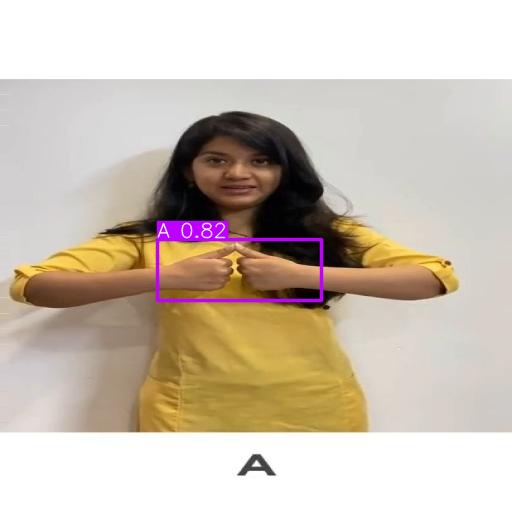


Detections for A_mp4-4_jpg.rf.677bc11380c37c8e66c0056ef90492a5.jpg:
  - A: 0.82

image 1/1 /content/Indian-Sign-Language-Detection-1/valid/images/Y_mp4-5_jpg.rf.d851e79cd9115685a99d05578235a8ca.jpg: 640x640 1 Y, 16.4ms
Speed: 3.4ms preprocess, 16.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


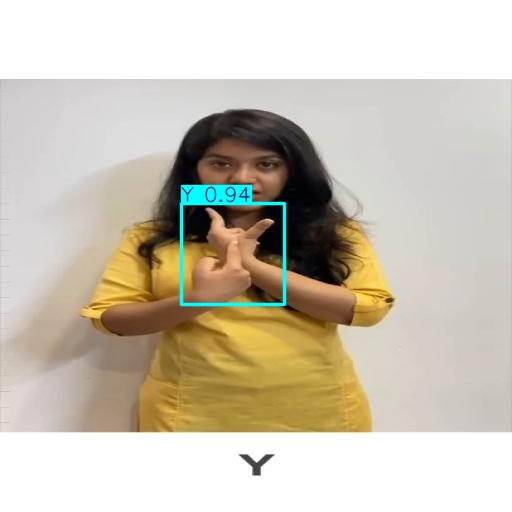


Detections for Y_mp4-5_jpg.rf.d851e79cd9115685a99d05578235a8ca.jpg:
  - Y: 0.94

image 1/1 /content/Indian-Sign-Language-Detection-1/valid/images/X_mp4-38_jpg.rf.dc61cbf3cd4bb2b4563d48a75bf86777.jpg: 640x640 1 X, 16.3ms
Speed: 3.6ms preprocess, 16.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


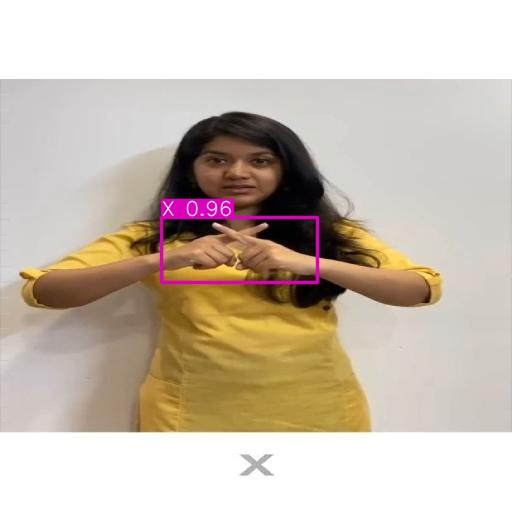


Detections for X_mp4-38_jpg.rf.dc61cbf3cd4bb2b4563d48a75bf86777.jpg:
  - X: 0.96

image 1/1 /content/Indian-Sign-Language-Detection-1/valid/images/J_mp4-23_jpg.rf.cfb3ee7823d5fdffd0d4c30bfb07e44a.jpg: 640x640 1 J, 16.4ms
Speed: 3.7ms preprocess, 16.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


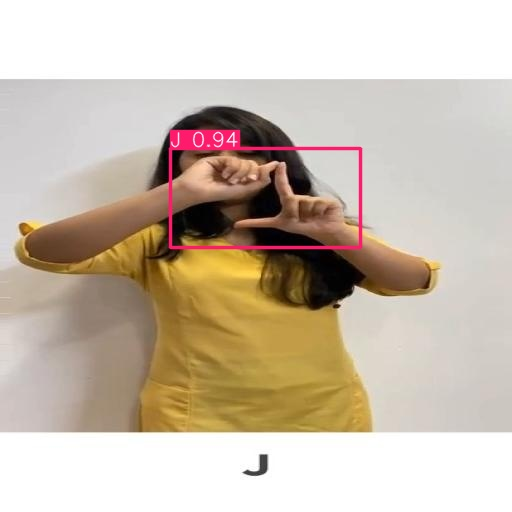


Detections for J_mp4-23_jpg.rf.cfb3ee7823d5fdffd0d4c30bfb07e44a.jpg:
  - J: 0.94


In [5]:
from IPython.display import Image, display
import glob
from pathlib import Path

# Check if model was trained, otherwise load from weights
weights_path = Path("runs/detect/isl_public_yolov8/weights/best.pt")

if weights_path.exists():
    best_model = YOLO(str(weights_path))
    print(f"Loaded model from: {weights_path}")
else:
    # Use the model from training step if weights don't exist yet
    try:
        best_model = model  # Use the model from Step 3
        print("Using model from training step (Step 3)")
    except NameError:
        print("ERROR: Please run Step 3 (Train YOLOv8 Model) first!")
        raise FileNotFoundError("Model weights not found. Train the model first in Step 3.")

# Test on validation images
test_images = glob.glob(str(DATASET_DIR / "valid" / "images" / "*.jpg"))[:5]

if len(test_images) == 0:
    print("No test images found. Checking alternate path...")
    test_images = glob.glob(str(DATASET_DIR / "val" / "images" / "*.jpg"))[:5]

for img_path in test_images:
    results = best_model(img_path)
    results[0].save(filename=f"result_{Path(img_path).name}")
    display(Image(filename=f"result_{Path(img_path).name}"))
    print(f"\nDetections for {Path(img_path).name}:")
    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        label = results[0].names[cls_id]
        print(f"  - {label}: {conf:.2f}")

## Step 6: Download Trained Weights

Run this cell to download the trained model to your local machine.

In [6]:
import os
from pathlib import Path
import glob

# Search for all best.pt files in the runs directory
print("Searching for trained weights...\n")

# Check if runs directory exists
if os.path.exists('runs'):
    # Find all best.pt files
    weight_files = glob.glob('runs/**/best.pt', recursive=True)

    if weight_files:
        print(f"Found {len(weight_files)} weight file(s):\n")
        for i, wf in enumerate(weight_files, 1):
            file_size = os.path.getsize(wf) / (1024*1024)  # Convert to MB
            print(f"{i}. {wf} ({file_size:.2f} MB)")

        # Use the first (or most recent) weights file
        latest_weights = weight_files[0]
        print(f"\nUsing: {latest_weights}")

        # Download in Colab
        try:
            from google.colab import files
            files.download(latest_weights)
            print("\nWeights downloaded successfully!")
            print(f"File: {os.path.basename(latest_weights)}")
        except ImportError:
            print(f"\nNot in Colab. Weights are at: {Path(latest_weights).absolute()}")
    else:
        print("No weight files found in runs directory!")
        print("\nLet's check what's in the runs folder:")
        for root, dirs, files in os.walk('runs'):
            level = root.replace('runs', '').count(os.sep)
            indent = ' ' * 2 * level
            print(f'{indent}{os.path.basename(root)}/')
            subindent = ' ' * 2 * (level + 1)
            for file in files[:10]:  # Show first 10 files
                print(f'{subindent}{file}')
else:
    print("'runs' directory not found!")
    print("\nThis means training hasn't completed or ran in a different session.")
    print("Please run Cell 6 (Step 3: Train YOLOv8 Model) again.")

Searching for trained weights...

Found 1 weight file(s):

1. runs/isl_public_yolov8/weights/best.pt (21.50 MB)

Using: runs/isl_public_yolov8/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Weights downloaded successfully!
File: best.pt


In [7]:
import os
import glob

# Check if we're in Colab and still have the model from training
print("🔍 Checking environment...\n")

# Check if model variable exists from training
try:
    if 'model' in dir():
        print("✅ Model object still exists in memory!")
        print("   You can use it without re-training.\n")
        has_model = True
    else:
        print("❌ Model object not in memory.\n")
        has_model = False
except:
    has_model = False

# Check for weight files
all_pt_files = glob.glob('**/*.pt', recursive=True)
print(f"📁 Found {len(all_pt_files)} .pt files total:\n")
for f in all_pt_files:
    size = os.path.getsize(f) / (1024*1024)
    print(f"   {f} ({size:.2f} MB)")

# Check specifically for best.pt
best_files = glob.glob('**/best.pt', recursive=True)
if best_files:
    print(f"\n✅ Found best.pt at: {best_files[0]}")
    print(f"   Size: {os.path.getsize(best_files[0]) / (1024*1024):.2f} MB")
    print("\n📥 Attempting download...")
    from google.colab import files
    files.download(best_files[0])
else:
    print("\n❌ No best.pt found.")
    print("\n⚠️ You need to re-run Cell 6 (Step 3: Train YOLOv8 Model)")
    print("   This will take 1-2 hours with GPU.")

🔍 Checking environment...

✅ Model object still exists in memory!
   You can use it without re-training.

📁 Found 4 .pt files total:

   yolov8s.pt (21.54 MB)
   yolo11n.pt (5.35 MB)
   runs/isl_public_yolov8/weights/last.pt (21.50 MB)
   runs/isl_public_yolov8/weights/best.pt (21.50 MB)

✅ Found best.pt at: runs/isl_public_yolov8/weights/best.pt
   Size: 21.50 MB

📥 Attempting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>